# 1.2 Elastic Modeling Basics

This tutorial repeats the acoustic workflow with isotropic elastic physics. The model uses the same two flat layers and the same shared `Vp`/`Rho` values as 1.1, then adds `Vs` so the material can support shear waves.

The second half copies the simulation, adds `Qp = 20` and `Qs = 10`, reruns it, and plots the non-attenuative and attenuative traces side by side. There is no separate viscous-physics option in the Python API; attenuation is requested by providing attenuation properties. The final section adds a single-frequency ParaView QC job so the elastic mesh, PML, material properties, and wavefield can be inspected visually.


## Imports

The examples use `import frequensolve as fs` throughout. Pint units come from `fs.ureg`, so each layer can mix numeric constants and unit-aware quantities while exporting a consistent solver input.


In [1]:
from pathlib import Path

import numpy as np
from IPython.display import Image, display
import frequensolve as fs

u = fs.ureg


## What This Adds To Acoustic

The workflow is the same as 1.1, but the physics supports vector displacement/velocity and stress. The tutorial is designed so the background `Vp` and `Rho` stay fixed; the new information is `Vs`, elastic receiver components, and the effect of adding `Qp`/`Qs` attenuation to a copied simulation.

By the end, you should be able to read an elastic layer table, choose compatible receiver fields, compare attenuative versus lossless traces, and request a frequency-domain ParaView QC job for mesh/field inspection.


## Elastic Material Properties

Elastic physics keeps the acoustic `Vp` and `Rho` values from 1.1 and adds `Vs`, allowing the material to support shear waves and mode conversion. Optional `Qp` and `Qs` are added later in a copied simulation so the unattenuated baseline stays explicit. The values below are expressed in the units shown; the permissible-property reference table uses dimensions so it remains independent of a particular unit system.

| Property | Unit | upper_layer | lower_layer | Meaning |
| --- | --- | ---: | ---: | --- |
| `Vp` | km/s | 2.0 | 2.8 | P-wave speed in the elastic frame. |
| `Vs` | km/s | 1.0 | 1.5 | S-wave speed; this is the main new property relative to the acoustic example. |
| `Rho` | g/cm^3 | 2.2 | 2.4 | Mass density shared with the acoustic example. |

The public elastic material vocabulary covers isotropic, VTI, and TTI parameterizations. The isotropic example below only needs the first three rows; anisotropy parameters are listed here so the accepted names are explicit.

| Property | Dimension | Applies to | Required | Short explanation |
| --- | --- | --- | --- | --- |
| `Vp` | L/T | `elastic:iso`, `elastic:vti`, `elastic:tti` | Yes | P-wave speed of the elastic frame. |
| `Vs` | L/T | `elastic:iso`, `elastic:vti`, `elastic:tti` | Yes | S-wave speed of the elastic frame. |
| `Rho` | M/L^3 | `elastic:iso`, `elastic:vti`, `elastic:tti` | Yes | Mass density. |
| `Qp` | 1 | all elastic modes | No | P-wave quality factor for attenuation. |
| `Qs` | 1 | all elastic modes | No | S-wave quality factor for attenuation. |
| `epsilon` | 1 | `elastic:vti`, `elastic:tti` | Required for anisotropic modes | Thomsen-style P-wave anisotropy parameter. |
| `gamma` | 1 | `elastic:vti`, `elastic:tti` | No | Thomsen-style S-wave anisotropy parameter. |
| `delta` | 1 | `elastic:vti`, `elastic:tti` | No | Thomsen-style near-vertical P-wave anisotropy parameter. |
| `phi` | angle | `elastic:tti` | No | Symmetry-axis azimuth/rotation for tilted transverse isotropy. |
| `theta` | angle | `elastic:tti` | No | Symmetry-axis tilt for tilted transverse isotropy. |


## Project, Simulation, And Layered Model

The next cell creates the project-owned elastic simulation and attaches the two-layer model. The layer construction mirrors the acoustic tutorial: the same flat geometry and shared `Vp`/`Rho` values are used, with `Vs` added to each layer. That consistency makes the trace comparison later about physics, not about a changed background model.


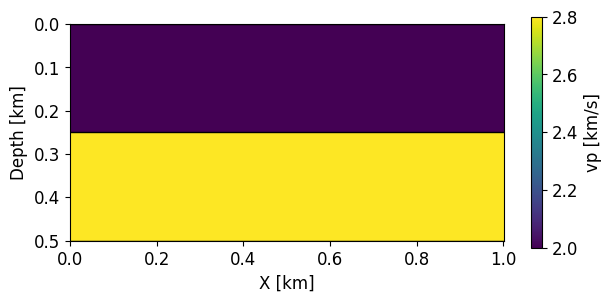

In [2]:
project = fs.Project(
    name="project",
    pretty_name="elastic_basic",
    path="./scratch/tutorials/elastic_basic",
    log_level="INFO",
    log_to_console=True,
)

sim = project.new_simulation(
    name="elastic_basic",
    physics="elastic",
    dimension=2,
    units={
        "length": "km",
        "velocity": "km/s",
        "density": "g/cm^3",
    },
)

model = fs.LayeredModel(name="model", dimension=2, x_limits=[0.0, 1.0])
model.add_surface(name="top", depth=0.0 * u.km)
model.add_layer(
    name="upper_layer",
    properties={
        "Vp": 2.0 * u.km / u.s,
        "Vs": 1.0 * u.km / u.s,
        "Rho": 2.2 * u.g / u.cm**3,
    },
)
model.add_surface(name="interface", depth=0.25 * u.km)
model.add_layer(
    name="lower_layer",
    properties={
        "Vp": 2.8 * u.km / u.s,
        "Vs": 1.5 * u.km / u.s,
        "Rho": 2.4 * u.g / u.cm**3,
    },
)
model.add_surface(name="bottom", depth=0.5 * u.km)
sim += model
model.plot("vp", figsize=(7, 3), aspect="equal");


## Mesh, Order, And Wavelength Sizing

The generated mesh is only the starting geometry. `sim.mesh.set_adapt(...)` defines the finite-element order and the frequency range used by solver-side refinement. For this notebook, `order=4` and `elems_per_wave=2` give roughly `order * elems_per_wave + 1` nodal points per shortest wavelength.

As in the acoustic case, PML is not a material layer in the model. Applying `pml` to a truncation boundary causes the solver to auto-extrude an absorbing layer outside the modeled domain. Because `pml_wavelengths` is measured in wavelengths, the physical PML width is frequency-dependent.


## Boundary Conditions And PML
| Boundary condition | Variables/components constrained | Typical use |
| --- | --- | --- |
| `free` | Mechanical traction trace `t_hat = 0`. | Stress-free surfaces, including the top boundary in this notebook. |
| `fixed` | Mechanical displacement trace `u_hat = 0` for all constrained displacement components. | Rigid or clamped boundaries. |
| `impedance` | Couples displacement/velocity trace components with traction trace components through an impedance relation. | Approximate radiation or absorbing boundary without a full PML. |
| `pml` | Absorbing-layer equations for all active elastic fields in the auto-extruded PML region. | Truncating the computational domain on sides and bottom. |

This notebook sets `pml_wavelengths=0.75` on the side and bottom boundaries. The default `pml_reflection` is `1e-3`; keep that moderate for small tutorials unless inspection shows boundary reflections that require a wider or stronger layer.


In [3]:
sim += model.hex_mesh_generator([8, 4])
sim.mesh.set_adapt(elems_per_wave=2.0, order=4, f_low=5.0, f_high=30.0)
sim.mesh.set_source_grading(d1=0.05, mult=2.0)

sim += fs.BoundaryCondition(
    conditions=["free"],
    boundaries=["z_min"],
)
sim += fs.BoundaryCondition(
    conditions=["pml"],
    boundaries=["x_min", "x_max", "z_max"],
    pml_wavelengths=0.75,
)


## Source And Receiver Components

Elastic sources are usually vector or moment mechanisms. Receiver components are selected by field plus direction. Here the source is a vertical vector force and the receiver measures vertical velocity, so the plotted traces isolate one clear elastic observable before the later attenuation comparison.


In [4]:
acq = fs.Acquisition()
acq.add_source_group(kind="vector", coords=fs.Q_([[0.5, 0.0]], "km"), direction=[0.0, 1.0])

receiver = fs.ReceiverNode(name="geophone")
receiver.add_component(name="v_z", field="velocity", direction=[0.0, 1.0])

receiver_coords = [fs.Q_([x, 0.0], "km") for x in np.linspace(0.0, 1.0, 201)]
acq.add_receiver_group(
    name="surface", 
    device=receiver,
    coords=receiver_coords
)
sim += acq

sim += fs.SolverConfig(ptol = 1.e-10)


## Run The Baseline Simulation

This solver cell is strict. If the local site is not configured or the fast solver fails, the notebook stops and the job logs should be inspected from the project `jobs/` directory.


In [5]:
site = fs.LocalSite(shutdown_on_completion=True, verbose=True)

job = fs.TimeDomainJob(
    name="time_no_q",
    simulation=sim,
    f_min=0.0,
    f_max=45.0,
    T_max=1.0,
)
result = site.submit(job).wait()
traces = result.traces(upscale=4)
traces.summary

2026-05-14 02:39:42,310 [INFO] frequensolve.orchestrator.sites.local:228 - Skipping job time_no_q; fingerprint matches and expected trace outputs exist.
2026-05-14 02:39:42,422 [INFO] frequensolve.orchestrator.sites.local:382 - LocalSite: skipped - Run is current


LocalSite: skipped - Run is current


surface
  Receivers	: 1 - 201
  Shot		: 1
  Components	: ['v_z']
  Frequencies	: 1.00 - 45.00 Hz (Δf=1.00)
  Window	: 0.00 - 1.00 s

## Plot The Baseline Traces

`RunResult.traces()` returns a `TraceDataset`. The time-domain read uses a wavelet to reconstruct a time series from the computed frequency-domain content, and the plotting helper operates on the returned `xarray.DataArray`.


In [6]:
wavelet = fs.RickerWavelet(f=15.0)
group = traces.groups[0]
component = traces.components(group)[0]
source = traces.sources(group)[0]
no_q = traces.td(group, component, source, wavelet, upscale=4)

## Copy The Simulation And Add Attenuation

`sim.copy(...)` is useful for controlled experiments: the mesh, model, acquisition, and numerical settings are cloned, then only the attenuation properties are changed. Providing `Qp` and `Qs` is the user-facing request for attenuative elastic material behavior.


In [7]:
attenuated = sim.copy("elastic_attenuated")
for layer in attenuated.model.layers:
    layer.properties["Qp"] = 20.0
    layer.properties["Qs"] = 10.0
project += attenuated

q_job = fs.TimeDomainJob(
    name="time_q",
    simulation=attenuated,
    f_min=0.0,
    f_max=45.0,
    T_max=1.0,
)
q_result = site.submit(q_job).wait()
q_traces = q_result.traces(upscale=4)
q_group = q_traces.groups[0]
q_component = q_traces.components(q_group)[0]
q_source = q_traces.sources(q_group)[0]
with_q = q_traces.td(q_group, q_component, q_source, wavelet, upscale=4)


2026-05-14 02:39:42,474 [INFO] frequensolve.orchestrator.sites.local:228 - Skipping job time_q; fingerprint matches and expected trace outputs exist.
2026-05-14 02:39:42,585 [INFO] frequensolve.orchestrator.sites.local:382 - LocalSite: skipped - Run is current


LocalSite: skipped - Run is current


## Compare Traces

The comparison plot uses the same receiver group, component, source, and wavelet for both runs. Differences therefore come from the material attenuation rather than from acquisition or processing changes.


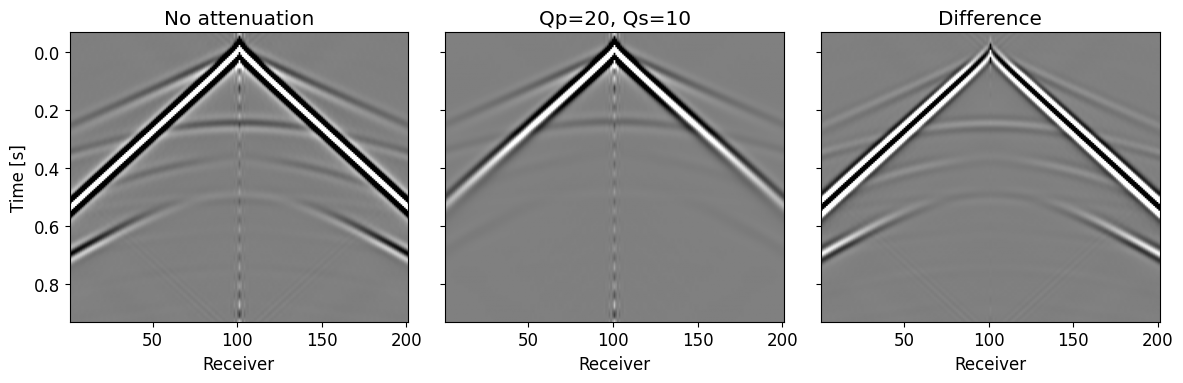

In [ ]:
fig, axes = fs.diff_gathers(
    no_q,
    with_q,
    A=max(np.std(np.abs(no_q.values)), np.std(np.abs(with_q.values))),
    cmap="gray",
    figsize=(12, 4),
    titles=("No attenuation", "Qp=20, Qs=10", "Difference"),
    T_max=1.0,
)


## Single-Frequency ParaView QC

The time-domain jobs above write receiver traces. ParaView output is owned by a separate frequency-domain job, which keeps visualization products tied to the frequency and output request that created them. This QC job writes the elastic wavefield together with the mesh, PML region, and material properties used by the baseline non-attenuative simulation.


In [9]:
site_fd = fs.LocalSite(shutdown_on_completion=True, verbose=True)
elastic_pv_output = fs.ParaviewOutput(
    name="pv_elastic",
    path="paraview",
    fields=["velocity", "stress"],
    properties=["vp", "vs", "rho", "Subdomain"],
    sources=[1],
    show_pml=True,
    upscale=1,
    order=2,
)

fd_job = fs.FrequencyDomainJob(
    name="freq_elastic_qc",
    simulation=sim,
    f_list=[25.0],
    outputs=[elastic_pv_output],
)
fd_result = site_fd.submit(fd_job).wait()
elastic_vtu_files = fd_result.output_files(base="pv_elastic", suffix=".vtu", existing=True)
elastic_vtu_files


2026-05-14 02:39:42,971 [INFO] frequensolve.orchestrator.sites.local:228 - Skipping job freq_elastic_qc; fingerprint matches and expected trace outputs exist.
2026-05-14 02:39:42,976 [INFO] frequensolve.orchestrator.sites.local:382 - LocalSite: skipped - Run is current


LocalSite: skipped - Run is current


[PosixPath('scratch/tutorials/elastic_basic/jobs/elastic_basic/freq_elastic_qc/results/paraview/pv_elastic_00000.vtu'),
 PosixPath('scratch/tutorials/elastic_basic/jobs/elastic_basic/freq_elastic_qc/results/ParaView/pv_elastic_00000.vtu')]

## Render The Elastic VTU

The files above are standard VTK/VTU outputs and can be opened directly in ParaView. For a persistent notebook preview, the cell below renders the exported `Vs` field with PyVista and saves a screenshot next to the tutorial assets.


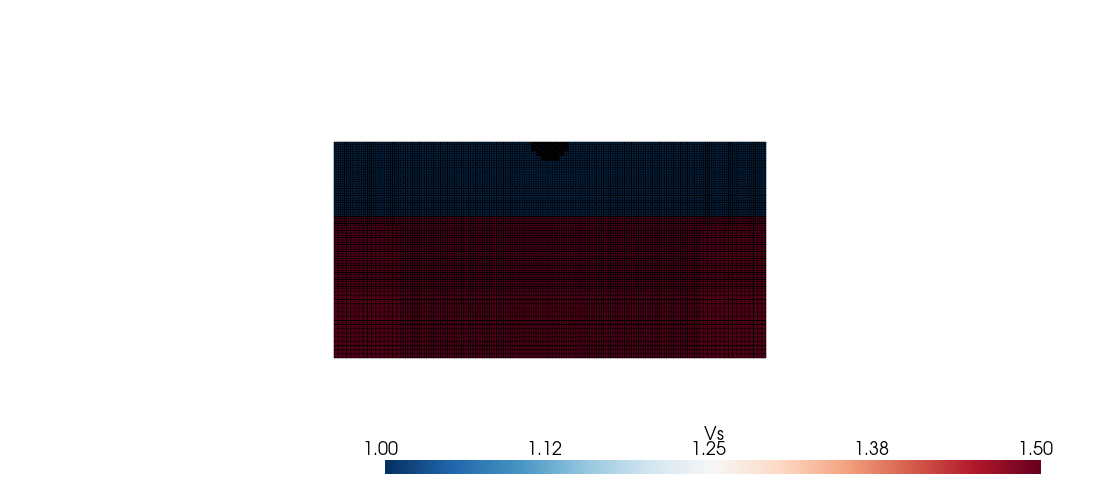

In [10]:
image_dir = Path("./tutorial_assets")
image_dir.mkdir(exist_ok=True)

elastic_screenshot = image_dir / "elastic_paraview_vs.png"
fs.plot_vtu(
    elastic_vtu_files[0],
    field="vs",
    part="real",
    show_edges=True,
    scalar_bar=True,
    show=False,
    screenshot=elastic_screenshot,
    window_size=(1100, 500),
)
display(Image(filename=str(elastic_screenshot)))


## Result Review Checklist

Elastic review should show both new physics and continuity with the acoustic workflow. The model, mesh, acquisition, job, trace, and ParaView patterns are the same; the field content and material interpretation are richer.

| Artifact | What it proves |
| --- | --- |
| Elastic property table | Shared `Vp`/`Rho` values match the acoustic baseline while `Vs` adds shear support. |
| Baseline trace panels | Vector receivers record multiple motion components from the same source. |
| Attenuative comparison | Adding `Qp` and `Qs` changes amplitudes/phase without changing the simulation physics string. |
| Frequency-domain VTU | Elastic material properties, PML, and vector fields are visible in ParaView/PyVista output. |
| Result logs | Solver and mesh behavior can be inspected separately from plotting choices. |
